In [1]:
# so the main idea is to embed the dance seq to 128 or 256 dim then label some of the dance seq and with the help of knn label rest of them 
# so in the data i will take the example by taking first 1600 timestamps and seq len 40 to generate 40 dance phrases and out of 40 i will label 
# 5 and let the knn label the rest 35 and see how the model does by testing it on two labeld data that i also labeled but did not gave to model 

In [3]:
# now there are two part in it ->
# 1st is how embeddings will get generated and 2nd is how i will label the generated seq
# i am thinking of a GNN to generate embedding as the nodes will become joint , edges will be the skeleton_lines and the node feature will be the dim
# and for the labeling part i will give it number for starfting like cateorical label out of 4 
# 0- tbd
# 1- tbd
# 2- tbd
# 3- tbd

In [5]:
# GNN 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class TemporalGNN(nn.Module):
    def __init__(self, input_dim=3, num_joints=25, embed_dim=128):
        super().__init__()
        self.fc = nn.Linear(num_joints * input_dim, embed_dim)
        self.gru = nn.GRU(embed_dim, embed_dim, batch_first=True)

    def forward(self, x):
        batch_size, seq_len, num_joints, dim = x.shape
        x = x.view(batch_size, seq_len, -1)  # Flatten joints
        x = self.fc(x)
        _, hidden = self.gru(x)
        return hidden.squeeze(0)  # [batch_size, embed_dim]

class TransformerDecoder(nn.Module):
    def __init__(self, embed_dim=128, num_joints=25, output_dim=3, seq_len=50, num_heads=4, num_layers=2):
        super().__init__()
        self.seq_len = seq_len
        self.fc_in = nn.Linear(embed_dim, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(seq_len, embed_dim))
        decoder_layer = nn.TransformerDecoderLayer(embed_dim, num_heads)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers)
        self.fc_out = nn.Linear(embed_dim, num_joints * output_dim)

    def forward(self, z):
        batch_size = z.shape[0]
        z = self.fc_in(z).unsqueeze(0).repeat(self.seq_len, 1, 1)  # [seq_len, batch, embed_dim]
        z = z + self.pos_embed.unsqueeze(1)
        z = self.transformer_decoder(z, z)
        z = self.fc_out(z).view(self.seq_len, batch_size, -1, 3)
        return z.permute(1, 0, 2, 3)  # [batch_size, seq_len, num_joints, 3]

class DanceAutoencoder(nn.Module):
    def __init__(self, input_dim=3, num_joints=25, embed_dim=128, seq_len=50):
        super().__init__()
        self.encoder = TemporalGNN(input_dim, num_joints, embed_dim)
        self.decoder = TransformerDecoder(embed_dim, num_joints, input_dim, seq_len)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

# Example usage
if __name__ == "__main__":
    batch_size, seq_len, num_joints, dim = 8, 50, 25, 3
    model = DanceAutoencoder()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    data = torch.randn(batch_size, seq_len, num_joints, dim)
    output = model(data)
    loss = criterion(output, data)
    loss.backward()
    optimizer.step()
    print("Loss:", loss.item())


In [329]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
from torch_geometric.nn import GCNConv, GATv2Conv, global_mean_pool
from torch_geometric.data import Data, Batch
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import networkx as nx
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
class TemporalGNN(nn.Module):
    def __init__(self, in_channels=3, hidden_channels=64, out_channels=128, num_layers=3):
        super(TemporalGNN, self).__init__()
        
        # GNN layers
        self.convs = nn.ModuleList()
        self.convs.append(GATv2Conv(in_channels, hidden_channels))
        
        for _ in range(num_layers - 2):
            self.convs.append(GATv2Conv(hidden_channels, hidden_channels))
        
        self.convs.append(GATv2Conv(hidden_channels, hidden_channels))
        
        # Temporal attention layers
        self.temporal_attn = nn.MultiheadAttention(embed_dim=hidden_channels, 
                                                  num_heads=4, 
                                                  batch_first=True)
        
        # Final MLP for embedding generation
        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, out_channels)
        )
        
    def forward(self, data_list):
        """
        Process a list of graph snapshots representing a dance sequence
        
        Args:
            data_list: List of torch_geometric Data objects, each representing a frame
                       in the motion sequence
        
        Returns:
            embeddings: The final dance sequence embedding
        """
        batch_size = len(data_list)
        seq_len = len(data_list[0])
        
        # Process each graph snapshot with GNN
        frame_embeddings = []
        
        for batch_idx in range(batch_size):
            sequence_embeddings = []
            
            for frame_idx in range(seq_len):
                data = data_list[batch_idx][frame_idx]
                x, edge_index = data.x, data.edge_index
                
                # Apply GNN layers
                for conv in self.convs:
                    x = conv(x, edge_index)
                    x = F.relu(x)
                    x = F.dropout(x, p=0.2, training=self.training)
                
                # Global pooling to get graph-level representation
                batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
                pooled = global_mean_pool(x, batch)
                
                sequence_embeddings.append(pooled)
                
            # Stack frame embeddings for this sequence
            sequence_embeddings = torch.stack(sequence_embeddings, dim=0)  # [seq_len, hidden_dim]
            
            # Apply temporal attention
            attn_out, _ = self.temporal_attn(sequence_embeddings, 
                                            sequence_embeddings, 
                                            sequence_embeddings)
            
            # Get sequence representation by averaging over frames
            seq_repr = attn_out.mean(dim=0)  # [hidden_dim]
            
            # Final embedding
            embedding = self.mlp(seq_repr)  # [out_channels]
            frame_embeddings.append(embedding)
            
        # Stack all sequence embeddings
        embeddings = torch.stack(frame_embeddings, dim=0)  # [batch_size, out_channels]
        
        return embeddings.squeeze(1)  # Removes extra dimension


def motion_to_graph_sequence(motion_data, point_labels, skeleton_lines):
    """
    Convert motion capture data to a sequence of graph snapshots
    
    Args:
        motion_data: numpy array of shape (n_frames, n_joints, 3)
        point_labels: list of joint names
        skeleton_lines: list of tuples defining the skeleton connections
    
    Returns:
        graph_sequence: list of torch_geometric Data objects
    """
    n_frames, n_joints, _ = motion_data.shape
    graph_sequence = []
    
    # Create mapping from joint names to indices
    joint_to_idx = {joint: i for i, joint in enumerate(point_labels)}
    
    # Build edge index from skeleton lines
    edges = []
    for connection in skeleton_lines:
        # Each connection is ((joint1,), (joint2,))
        src_joint = connection[0][0]
        dst_joint = connection[1][0]
        
        if src_joint in joint_to_idx and dst_joint in joint_to_idx:
            src_idx = joint_to_idx[src_joint]
            dst_idx = joint_to_idx[dst_joint]
            edges.append([src_idx, dst_idx])
            edges.append([dst_idx, src_idx])  # Add bidirectional edges
    
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    
    # Create a graph for each frame
    for frame_idx in range(n_frames):
        # Node features are the 3D positions
        x = torch.tensor(motion_data[frame_idx], dtype=torch.float)
        
        # Create graph data object
        data = Data(x=x, edge_index=edge_index)
        graph_sequence.append(data)
    
    return graph_sequence


def prepare_batched_sequences(motion_data, point_labels, skeleton_lines, seq_length=30, stride=15):
    """
    Prepare batched sequences of motion data
    
    Args:
        motion_data: numpy array of shape (n_frames, n_joints, 3)
        point_labels: list of joint names
        skeleton_lines: list of tuples defining the skeleton connections
        seq_length: length of each sequence
        stride: stride between consecutive sequences
    
    Returns:
        batched_sequences: list of lists of torch_geometric Data objects
    """
    n_frames = motion_data.shape[0]
    batched_sequences = []
    
    # Create sequences with sliding window
    for start_idx in range(0, n_frames - seq_length + 1, stride):
        end_idx = start_idx + seq_length
        sequence_data = motion_data[start_idx:end_idx]
        
        # Convert to graph sequence
        graph_sequence = motion_to_graph_sequence(sequence_data, point_labels, skeleton_lines)
        batched_sequences.append(graph_sequence)
    
    return batched_sequences


def train_gnn(motion_data, point_labels, skeleton_lines, seq_length=30, stride=15, 
             batch_size=16, epochs=50, learning_rate=0.001):
    """
    Train the GNN model on motion data
    
    Args:
        motion_data: numpy array of shape (n_frames, n_joints, 3)
        point_labels: list of joint names
        skeleton_lines: list of tuples defining the skeleton connections
        seq_length: length of each sequence
        stride: stride between consecutive sequences
        batch_size: batch size for training
        epochs: number of training epochs
        learning_rate: learning rate for the optimizer
    
    Returns:
        model: trained model
        embeddings: generated embeddings for all sequences
    """
    # Prepare data
    sequences = prepare_batched_sequences(motion_data, point_labels, skeleton_lines, 
                                         seq_length, stride)
    
    # Create model
    model = TemporalGNN()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # Train model
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        
        # Process in batches
        for i in tqdm(range(0, len(sequences), batch_size)):
            batch_sequences = sequences[i:i + batch_size]
            
            # Forward pass
            embeddings = model(batch_sequences)
            
            # Compute triplet loss
            # We'll use random triplets for simplicity
            # In real applications, you might want to use more sophisticated triplet mining
            anchor = embeddings
            
            # Create positive examples by adding small noise
            positive = anchor + torch.randn_like(anchor) * 0.05
            
            # Create negative examples by shuffling the batch
            negative_idx = torch.randperm(len(batch_sequences))[:len(batch_sequences)]
            negative = embeddings[negative_idx]
            
            # Compute triplet loss
            distance_pos = F.pairwise_distance(anchor, positive)
            distance_neg = F.pairwise_distance(anchor, negative)
            
            # Margin triplet loss
            margin = 1.0
            loss = F.relu(distance_pos - distance_neg + margin).mean()
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")
    
    # Generate embeddings for all sequences
    model.eval()
    all_embeddings = []
    
    with torch.no_grad():
        for i in range(0, len(sequences), batch_size):
            batch_sequences = sequences[i:i + batch_size]
            embeddings = model(batch_sequences)
            all_embeddings.append(embeddings)
    
    all_embeddings = torch.cat(all_embeddings, dim=0).numpy()
    
    return model, all_embeddings

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize_embeddings(embeddings):
    """
    Visualize the embeddings using t-SNE without labels
    
    Args:
        embeddings: numpy array of embeddings
    """
    # Apply t-SNE for dimensionality reduction
    tsne = TSNE(n_components=2, random_state=0,n_jobs=1,method='exact')
    embeddings_2d = tsne.fit_transform(embeddings)
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7)
    plt.title('t-SNE Visualization of Dance Sequence Embeddings')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.tight_layout()
    plt.show()
    plt.savefig('dance_embeddings.png')
    plt.close()

In [647]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

point_labels = ['ARIEL', 'C7', 'CLAV', 'LANK', 'LBHD', 'LBSH', 'LBWT', 'LELB', 'LFHD', 'LFRM', 
                'LFSH', 'LFWT', 'LHEL', 'LIEL', 'LIHAND', 'LIWR', 'LKNE', 'LKNI', 'LMT1', 'LMT5', 
                'LOHAND', 'LOWR', 'LSHN', 'LTHI', 'LTOE', 'LUPA', 'MBWT', 'MFWT', 'RANK', 'RBHD', 
                'RBSH', 'RBWT', 'RELB', 'RFHD', 'RFRM', 'RFSH', 'RFWT', 'RHEL', 'RIEL', 'RIHAND', 
                'RIWR', 'RKNE', 'RKNI', 'RMT1', 'RMT5', 'ROHAND', 'ROWR', 'RSHN', 'RTHI', 'RTOE', 
                'RUPA', 'STRN', 'T10']
                
skeleton_lines = [
    (('LHEL',), ('LTOE',)), (('RHEL',), ('RTOE',)), (('LMT1',), ('LMT5',)), (('RMT1',), ('RMT5',)),
    (('LHEL',), ('LMT1',)), (('LHEL',), ('LMT5',)), (('RHEL',), ('RMT1',)), (('RHEL',), ('RMT5',)),
    (('LTOE',), ('LMT1',)), (('LTOE',), ('LMT5',)), (('RTOE',), ('RMT1',)), (('RTOE',), ('RMT5',)),
    (('LKNE',), ('LHEL',)), (('RKNE',), ('RHEL',)), (('LFWT',), ('RBWT',)), (('RFWT',), ('LBWT',)),
    (('LFWT',), ('RFWT',)), (('LBWT',), ('RBWT',)), (('LFWT',), ('LBWT',)), (('RFWT',), ('RBWT',)),
    (('LFWT',), ('LTHI',)), (('RFWT',), ('RTHI',)), (('LBWT',), ('LTHI',)), (('RBWT',), ('RTHI',)),
    (('LKNE',), ('LTHI',)), (('RKNE',), ('RTHI',)), 
    (('CLAV',), ('RFSH',)),
    (('STRN',), ('LFSH',)), (('STRN',), ('RFSH',)), (('T10',), ('LFSH',)), (('T10',), ('RFSH',)),
    (('C7',), ('LBSH',)), (('C7',), ('RBSH',)), (('LFSH',), ('LBSH',)), (('RFSH',), ('RBSH',)),
    (('LFSH',), ('RBSH',)), (('RFSH',), ('LBSH',)), (('LFSH',), ('LUPA',)), (('RFSH',), ('RUPA',)),
    (('LBSH',), ('LUPA',)), (('RBSH',), ('RUPA',)), (('LIWR',), ('LIHAND',)), (('RIWR',), ('RIHAND',)),
    (('LOWR',), ('LOHAND',)), (('ROWR',), ('ROHAND',)), (('LIWR',), ('LOWR',)), (('RIWR',), ('ROWR',)),
    (('LIHAND',), ('LOHAND',)), (('RIHAND',), ('ROHAND',)), (('LFHD',), ('LBHD',)), (('LBHD',), ('RBHD',)),
    (('RBHD',), ('RFHD',)), (('RFHD',), ('LFHD',)), (('LFHD',), ('ARIEL',)), (('LBHD',), ('ARIEL',)),
    (('RBHD',), ('ARIEL',)), 
    (('RFHD',), ('ARIEL',)),
    (('RFWT',), ('MFWT',)),(('LFWT',), ('MFWT',)),(('LFSH',), ('RFSH',))
]

file_path = "../data/mariel_betternot_and_retrograde.npy"  # Replace with your data file
motion_data = np.load(file_path)[:,:4000,:]
motion_data=motion_data.transpose(1,0,2)
print(f"Loaded motion data with shape: {motion_data.shape}")

model, embeddings = train_gnn(
    motion_data=motion_data,
    point_labels=point_labels,
    skeleton_lines=skeleton_lines,
    seq_length=100,         # Length of each dance stequence
    stride=100,             # Overlap between sequences
    batch_size=32,         # Training batch size
    epochs=2,             # Number of training epochs
    learning_rate=0.001    # Learning rate
)

print(f"Generated {embeddings.shape[0]} embeddings with dimension {embeddings.shape[1]}")

Loaded motion data with shape: (4000, 55, 3)


  0%|                                                                                                | 0/1 [00:00<?, ?it/s]Exception ignored in: <function PluginV3.__del__ at 0x31f215a80>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/imageio/core/v3_plugin_api.py", line 370, in __del__
    self.close()
  File "/opt/anaconda3/lib/python3.12/site-packages/imageio/plugins/pillow.py", line 144, in close
    self._flush_writer()
  File "/opt/anaconda3/lib/python3.12/site-packages/imageio/plugins/pillow.py", line 485, in _flush_writer
    primary_image.save(self._request.get_file(), **self.save_args)
  File "/opt/anaconda3/lib/python3.12/site-packages/PIL/Image.py", line 2568, in save
    save_handler(self, fp, filename)
  File "/opt/anaconda3/lib/python3.12/site-packages/PIL/GifImagePlugin.py", line 737, in _save_all
    _save(im, fp, filename, save_all=True)
  File "/opt/anaconda3/lib/python3.12/site-packages/PIL/GifImagePlugin.py", line 750, in _sa

Epoch 1/2, Loss: 1.4946


100%|████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:13<00:00, 13.40s/it]


Epoch 2/2, Loss: 1.4540
Generated 40 embeddings with dimension 128


In [17]:
# now got the embeddings 

In [657]:
emb.shape

(40, 128)

In [648]:
emb = embeddings

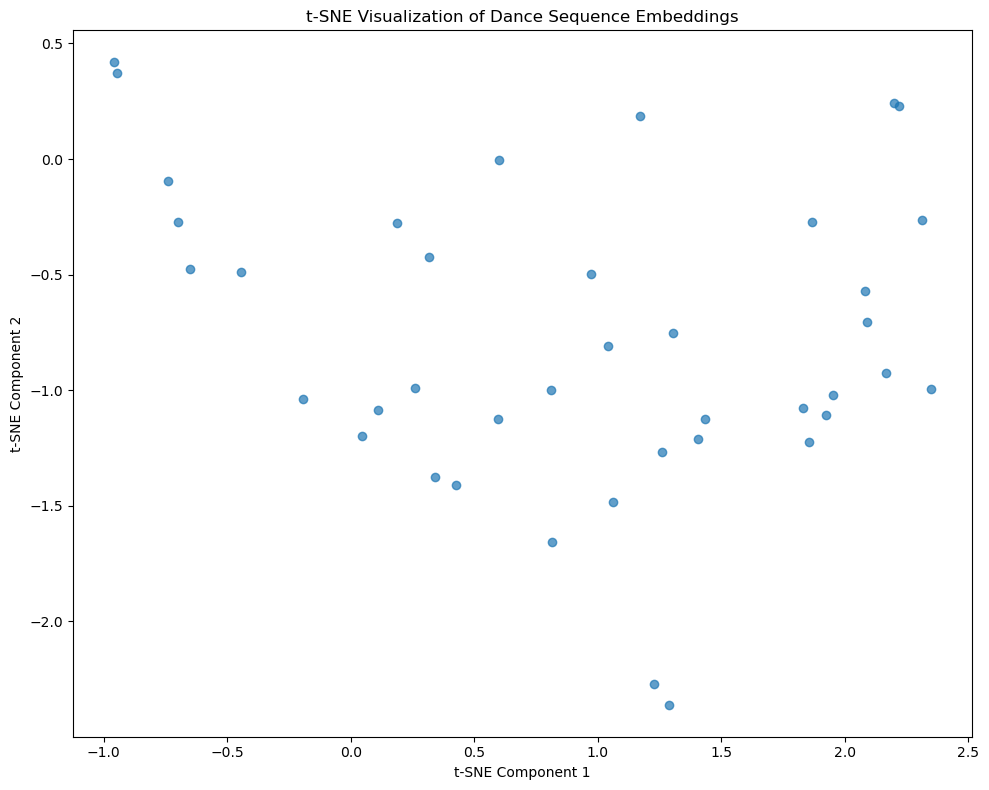

In [649]:
visualize_embeddings(emb)

In [47]:
import os
os.environ["JOBLIB_MULTIPROCESSING"] = "0"

In [55]:
!pip install joblib

In [63]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Assume we have 40 embeddings of shape (40, 128)
# embeddings = np.random.rand(40, 128)  # Replace this with actual embeddings

# Manually label 5 sequences (indices and their labels)
labeled_indices = [0, 5, 10, 15, 20]  # Example indices of labeled sequences
labels = [1, 0, 1, 3, 2]  # Corresponding labels

# Separate labeled and unlabeled data
X_labeled = embeddings[labeled_indices]
y_labeled = np.array(labels)

X_unlabeled = np.delete(embeddings, labeled_indices, axis=0)

# Train KNN classifier
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean',n_jobs=1,algorithm='kd_tree')  # Use 3 nearest neighbors
knn.fit(X_labeled, y_labeled)

# Predict labels for the remaining 35 sequences
predicted_labels = knn.predict(X_unlabeled)

# Combine labeled and predicted labels
final_labels = np.full(40, -1)  # Initialize all labels as -1 (unknown)
final_labels[labeled_indices] = y_labeled  # Assign known labels
final_labels[np.delete(np.arange(40), labeled_indices)] = predicted_labels  # Assign predicted labels

print(final_labels)  # Final labels for all 40 sequences

[1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 3 1 1 1 1 2 1 1 1 0 0 0 0 0 0 0 0 1 1 1 0 1
 1 1 1]


In [371]:
#labels and skeleton connections (from original code)
point_labels = ['ARIEL', 'C7', 'CLAV', 'LANK', 'LBHD', 'LBSH', 'LBWT', 'LELB', 'LFHD', 'LFRM', 
                'LFSH', 'LFWT', 'LHEL', 'LIEL', 'LIHAND', 'LIWR', 'LKNE', 'LKNI', 'LMT1', 'LMT5', 
                'LOHAND', 'LOWR', 'LSHN', 'LTHI', 'LTOE', 'LUPA', 'MBWT', 'MFWT', 'RANK', 'RBHD', 
                'RBSH', 'RBWT', 'RELB', 'RFHD', 'RFRM', 'RFSH', 'RFWT', 'RHEL', 'RIEL', 'RIHAND', 
                'RIWR', 'RKNE', 'RKNI', 'RMT1', 'RMT5', 'ROHAND', 'ROWR', 'RSHN', 'RTHI', 'RTOE', 
                'RUPA', 'STRN', 'T10']
skeleton_lines = [
    (('LHEL',), ('LTOE',)), (('RHEL',), ('RTOE',)), (('LMT1',), ('LMT5',)), (('RMT1',), ('RMT5',)),
    (('LHEL',), ('LMT1',)), (('LHEL',), ('LMT5',)), (('RHEL',), ('RMT1',)), (('RHEL',), ('RMT5',)),
    (('LTOE',), ('LMT1',)), (('LTOE',), ('LMT5',)), (('RTOE',), ('RMT1',)), (('RTOE',), ('RMT5',)),
    (('LKNE',), ('LHEL',)), (('RKNE',), ('RHEL',)), (('LFWT',), ('RBWT',)), (('RFWT',), ('LBWT',)),
    (('LFWT',), ('RFWT',)), (('LBWT',), ('RBWT',)), (('LFWT',), ('LBWT',)), (('RFWT',), ('RBWT',)),
    (('LFWT',), ('LTHI',)), (('RFWT',), ('RTHI',)), (('LBWT',), ('LTHI',)), (('RBWT',), ('RTHI',)),
    (('LKNE',), ('LTHI',)), (('RKNE',), ('RTHI',)), 
    (('CLAV',), ('RFSH',)),
    (('STRN',), ('LFSH',)), (('STRN',), ('RFSH',)), (('T10',), ('LFSH',)), (('T10',), ('RFSH',)),
    (('C7',), ('LBSH',)), (('C7',), ('RBSH',)), (('LFSH',), ('LBSH',)), (('RFSH',), ('RBSH',)),
    (('LFSH',), ('RBSH',)), (('RFSH',), ('LBSH',)), (('LFSH',), ('LUPA',)), (('RFSH',), ('RUPA',)),
    (('LBSH',), ('LUPA',)), (('RBSH',), ('RUPA',)), (('LIWR',), ('LIHAND',)), (('RIWR',), ('RIHAND',)),
    (('LOWR',), ('LOHAND',)), (('ROWR',), ('ROHAND',)), (('LIWR',), ('LOWR',)), (('RIWR',), ('ROWR',)),
    (('LIHAND',), ('LOHAND',)), (('RIHAND',), ('ROHAND',)), (('LFHD',), ('LBHD',)), (('LBHD',), ('RBHD',)),
    (('RBHD',), ('RFHD',)), (('RFHD',), ('LFHD',)), (('LFHD',), ('ARIEL',)), (('LBHD',), ('ARIEL',)),
    (('RBHD',), ('ARIEL',)), 
    (('RFHD',), ('ARIEL',)),
    (('RFWT',), ('MFWT',)),(('LFWT',), ('MFWT',)),(('LFSH',), ('RFSH',)) # added 
]
# from pirounet paper simpler representation
skeleton_lines2 = [
    #     ( (start group), (end group) ),
    (("LHEL",), ("LTOE",)),  # toe to heel
    (("RHEL",), ("RTOE",)),
    (("LKNE", "LKNI"), ("LHEL",)),  # heel to knee
    (("RKNE", "RKNI"), ("RHEL",)),
    (("LKNE", "LKNI"), ("LFWT", "RFWT", "LBWT", "RBWT")),  # knee to "navel"
    (("RKNE", "RKNI"), ("LFWT", "RFWT", "LBWT", "RBWT")),
    (
        ("LFWT", "RFWT", "LBWT", "RBWT"),
        (
            "STRN",
            "T10",
        ),
    ),  # "navel" to chest
    (
        (
            "STRN",
            "T10",
        ),
        (
            "CLAV",
            "C7",
        ),
    ),  # chest to neck
    (
        (
            "CLAV",
            "C7",
        ),
        (
            "LFSH",
            "LBSH",
        ),
    ),  # neck to shoulders
    (
        (
            "CLAV",
            "C7",
        ),
        (
            "RFSH",
            "RBSH",
        ),
    ),
    (
        (
            "LFSH",
            "LBSH",
        ),
        (
            "LELB",
            "LIEL",
        ),
    ),  # shoulders to elbows
    (
        (
            "RFSH",
            "RBSH",
        ),
        (
            "RELB",
            "RIEL",
        ),
    ),
    (
        (
            "LELB",
            "LIEL",
        ),
        (
            "LOWR",
            "LIWR",
        ),
    ),  # elbows to wrist
    (
        (
            "RELB",
            "RIEL",
        ),
        (
            "ROWR",
            "RIWR",
        ),
    ),
    (("LFHD",), ("LBHD",)),  # draw lines around circumference of the head
    (("LBHD",), ("RBHD",)),
    (("RBHD",), ("RFHD",)),
    (("RFHD",), ("LFHD",)),
    (("LFHD",), ("ARIEL",)),  # connect circumference points to top of head
    (("LBHD",), ("ARIEL",)),
    (("RBHD",), ("ARIEL",)),
    (("RFHD",), ("ARIEL",)),
]

reduced_joint_names = [
    'ARIEL', 'C7', 'CLAV', 'STRN',  # Head & Spine
    'RFSH', 'LFSH', 'RBSH', 'LBSH',  # Shoulders
    'RIEL', 'LIEL', 'RIWR', 'LIWR',  # Elbows & Wrists
    'RKNE', 'LKNE', 'RTOE', 'LTOE',  # Knees & Toes
    'RHEL', 'LHEL',  # Heels
    'RFWT', 'LFWT', 'RBWT', 'LBWT',  # Hip/Pelvis
    'RTHI', 'LTHI', 'RSHN', 'LSHN'  # Thighs & Shins
]
def create_skeleton(points, labels, connections, show_points=True, reduced_joint_names=None):
    label_to_idx = {label: i for i, label in enumerate(labels)}
    valid_indices = (np.arange(len(labels)) if reduced_joint_names is None 
                     else np.array([label_to_idx[j] for j in reduced_joint_names if j in label_to_idx]))
    if len(valid_indices) < 2:
        raise ValueError("At least two valid joints are needed.")
    
    index_map = {old: new for new, old in enumerate(valid_indices)}
    
    lines = np.hstack([[2, index_map[s], index_map[e]] 
                      for a, b in connections 
                      if (s := label_to_idx.get(a[0])) in index_map 
                      and (e := label_to_idx.get(b[0])) in index_map]).astype(np.int32)
    
    mesh = pv.PolyData(np.asarray(points)[valid_indices])
    if lines.size > 0:
        mesh.lines = lines
    
    return mesh, 10 if show_points else 0
def create_skeleton2(points, show_points=True): #for face triangle colour
    points = np.array(points)
    if points.shape[1] != 3 or len(points) < 2:
        raise ValueError("Points must have shape (N,3) with at least two points.")
    lines = np.array([(2, i, i + 1) for i in range(len(points) - 1)], dtype=np.int32).flatten()
    if len(points) == 3:
        lines = np.append(lines, [2, 2, 0])

    mesh = pv.PolyData(points)
    if lines.size > 0:
        mesh.lines = lines

    return mesh, 10 if show_points else 0
import os
import numpy as np
import cv2
import pyvista as pv
import imageio.v2 as iio
from tqdm import tqdm

def generate_skeleton_animation(data, output_name="skeleton_animation", stride=1, fps=24):
    plotter = pv.Plotter(off_screen=True, window_size=(640, 480))  

    label_to_idx = {label: idx for idx, label in enumerate(point_labels)}
    head_indices = np.array([0, 8, 33])  

    all_points = data.reshape(-1, data.shape[-1])
    global_min = all_points.min(axis=0)
    global_max = all_points.max(axis=0)
    global_center = (global_min + global_max) / 2
    global_diagonal = np.linalg.norm(global_max - global_min)
    global_view_distance = global_diagonal * 1.5

    camera_position = [
        global_center[0] + global_view_distance * 0.5,
        global_center[1] + global_view_distance * 0.3,
        global_center[2] + global_view_distance * 0.4
    ]

    plotter.camera_position = [camera_position, global_center, [0, 0, 1]]
    plotter.reset_camera()
    plotter.camera.zoom(2.0) 
    prev_frame = data[0]
    start_saving = False  
    movement_threshold = 0.001 * global_diagonal  
    total_frames = min(data.shape[0], 1500)  

    output_gif = f"{output_name}.gif"
    output_mp4 = f"{output_name}.mp4"

    with iio.get_writer(output_gif, mode="I", duration=int(1000 / fps)) as gif_writer:
        video_writer = None

        for t in tqdm(range(0, total_frames, stride)):
            current_frame = data[t]
            movement = np.linalg.norm(current_frame - prev_frame)

            if movement > movement_threshold or t > 200:
                start_saving = True 

            if start_saving:
                frame_center = current_frame.mean(axis=0)
                camera_position = [
                    frame_center[0] + global_view_distance * 0.5,
                    frame_center[1] + global_view_distance * 0.3,
                    frame_center[2] + global_view_distance * 0.4
                ]
                plotter.camera_position = [camera_position, frame_center, [0, 0, 1]]

                mesh, point_size = create_skeleton(current_frame, point_labels, skeleton_lines, show_points=True)
                mesh2, point_size2 = create_skeleton2(current_frame[head_indices], show_points=True)
                # point_size=0
                # point_size2=0
                plotter.add_mesh(mesh, render_lines_as_tubes=True, line_width=2, point_size=point_size/1.25 , color='black')
                plotter.add_mesh(mesh2, render_lines_as_tubes=True, line_width=3, point_size=point_size2 * 1.1, color='red')

                img = plotter.screenshot(return_img=True)
                frame = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR)

                gif_writer.append_data(frame)

                if video_writer is None:
                    height, width, _ = frame.shape
                    video_writer = cv2.VideoWriter(output_mp4, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

                video_writer.write(frame)
                plotter.clear_actors()

            prev_frame = current_frame  

            if t % 100 == 0:
                plotter.close()
                del plotter
                plotter = pv.Plotter(off_screen=True, window_size=(640, 480))  
                plotter.camera_position = [camera_position, global_center, [0, 0, 1]]
                plotter.camera.zoom(0.9) 

        if video_writer:
            video_writer.release()

    plotter.close()
    del plotter  

    print(f"Saved {output_gif} and {output_mp4}")

In [373]:
motion_data.shape

(55, 1600, 3)

In [513]:
file_path = "../data/mariel_betternot_and_retrograde.npy"  # Replace with your data file
motion_data = np.load(file_path)[:,:4000,:]

In [515]:
motion_data.shape

(55, 4000, 3)

In [843]:
from IPython.display import Image
def preprocesss(dat):
    data = dat.transpose(1, 0, 2)  
    point_mask = np.ones(55, dtype=bool)
    point_mask[[26,53]] = False
    data = data[:, point_mask, :]  # Now (timesteps, 53, 3)
    
    # Invert Z-axis (matching original processing)
    data[..., 2] *= -1
    return data
def visualize(index,data,seq_len,filename='temp'):
    path = os.path.join("animate", f"{filename}")
    inp = preprocesss(data)[index:index+seq_len]
    print(inp.shape,inp.type)
    generate_skeleton_animation(inp,output_name=path)

In [845]:
visualize(i,motion_data,100,filename='temp'+str(i))

AttributeError: 'numpy.ndarray' object has no attribute 'type'

In [531]:
import pandas as pd
data = {
    'index of the starting if seq': [i for i in range(10)],
    'label': [i for i in range(10)] 
}
df = pd.DataFrame(data)

In [533]:
df

,index of the starting if seq,label
0,0,0
1,1,1
2,2,2
3,3,3
4,4,4
5,5,5
6,6,6
7,7,7
8,8,8
9,9,9


In [535]:
embeddings.shape

(40, 128)

In [711]:
motion_data.shape

(4000, 55, 3)

In [713]:
j=-1
starting =200

In [715]:
for i in range(starting,motion_data.shape[1],100):
    visualize(i,motion_data,100,filename='temp'+str(i))
    j+=1
    idx = i
    starting+=50
    break

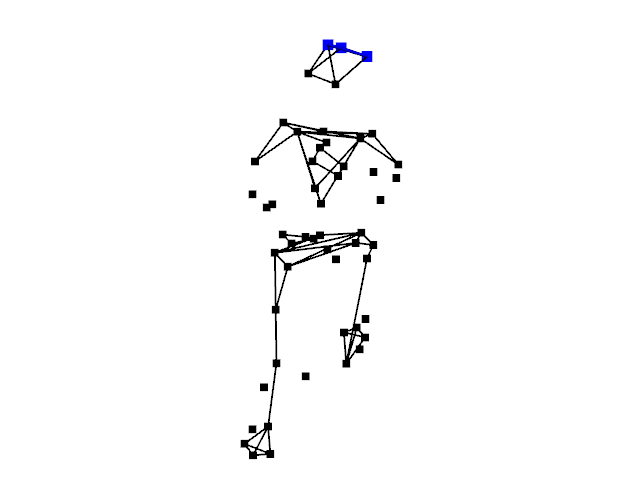

In [628]:
Image(filename=f'animate/{'temp'+str(idx)}.gif')

In [635]:
# temp1200 - 1

In [637]:
# label = 1
# df.iloc[j,1] = label

In [835]:
df.iloc[0,1] = 2
df.iloc[1,1] = 0
df.iloc[2,1] = 3
df.iloc[3,1] = 2
df.iloc[4,1] = 0
df.iloc[5,1] = 3
df.iloc[6,1] = 2
df.iloc[7,1] = 0
df.iloc[8,1] = 3
df.iloc[9,1] = 3

In [837]:
df

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,label
0,-0.101021,2.000000,-0.070533,0.202322,0.046178,-0.087222,0.175257,-0.151714,-0.102938,-0.021144,...,-0.115163,0.094365,0.074048,-0.105775,0.067022,-0.060914,0.106859,0.009942,-0.238929,2
1,-0.098596,0.000000,-0.067977,0.196279,0.045547,-0.085015,0.170954,-0.143166,-0.102404,-0.019555,...,-0.114347,0.087750,0.071763,-0.101996,0.068289,-0.064666,0.100865,0.008461,-0.229163,0
2,-0.077007,3.000000,-0.046766,0.159018,0.037479,-0.062865,0.156353,-0.089539,-0.081694,-0.002638,...,-0.111176,0.049509,0.054735,-0.060997,0.077246,-0.085894,0.062744,-0.006692,-0.164449,3
3,-0.074653,2.000000,-0.040918,0.148727,0.037345,-0.042543,0.166113,-0.085774,-0.066367,0.001650,...,-0.107374,0.046246,0.051400,-0.041869,0.079264,-0.087485,0.059889,-0.016944,-0.159586,2
4,-0.074599,0.000000,-0.040669,0.147990,0.037279,-0.041878,0.165902,-0.085245,-0.065821,0.001842,...,-0.106969,0.045884,0.051369,-0.041567,0.079675,-0.087164,0.059702,-0.017020,-0.159602,3
5,-0.073476,3.000000,-0.036384,0.135505,0.034091,-0.038542,0.155561,-0.070877,-0.061844,0.002303,...,-0.097950,0.041611,0.054021,-0.045583,0.085278,-0.083543,0.054097,-0.011085,-0.157830,1
6,-0.071912,2.000000,-0.028075,0.125505,0.032746,-0.033322,0.146249,-0.057655,-0.059342,-0.000782,...,-0.091123,0.036753,0.058910,-0.051089,0.093618,-0.074539,0.046028,-0.006811,-0.158712,2
7,-0.083832,0.000000,-0.034272,0.140517,0.037353,-0.052265,0.142425,-0.057663,-0.072058,-0.005481,...,-0.102608,0.041539,0.054025,-0.062651,0.096100,-0.071950,0.045245,-0.000100,-0.160856,2
8,-0.077801,3.000000,-0.039694,0.142573,0.033520,-0.051061,0.152770,-0.070122,-0.071143,-0.000136,...,-0.105241,0.044457,0.055093,-0.053112,0.084847,-0.086084,0.052094,-0.005901,-0.155909,3
9,-0.089209,3.000000,-0.037612,0.147198,0.038026,-0.052548,0.144978,-0.064481,-0.074752,-0.008342,...,-0.101895,0.046300,0.052619,-0.064574,0.092466,-0.072627,0.051232,-0.002870,-0.167915,3


In [655]:
emb.shape

(40, 128)

In [667]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Assume we have 40 embeddings of shape (40, 128)
# embeddings = np.random.rand(40, 128)  # Replace this with actual embeddings

# Manually label 5 sequences (indices and their labels)
labeled_indices = [i for i in range(len(df))]  # Example indices of labeled sequences
labels = list(df['label'])  # Corresponding labels

In [671]:
labeled_indices , labels

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], [2, 0, 3, 2, 3, 1, 2, 2, 3, 3])

In [673]:
# Separate labeled and unlabeled data
X_labeled = embeddings[labeled_indices]
y_labeled = np.array(labels)

In [679]:
X_labeled.shape , y_labeled.shape

((10, 128), (10,))

In [685]:
X_unlabeled = np.delete(embeddings, labeled_indices, axis=0)

In [687]:
# Train KNN classifier
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean',n_jobs=1,algorithm='kd_tree')  # Use 3 nearest neighbors
knn.fit(X_labeled, y_labeled)

# Predict labels for the remaining 35 sequences
predicted_labels = knn.predict(X_unlabeled)

In [689]:
# Combine labeled and predicted labels
final_labels = np.full(emb.shape[0], -1)  # Initialize all labels as -1 (unknown)
final_labels[labeled_indices] = y_labeled  # Assign known labels
final_labels[np.delete(np.arange(emb.shape[0]), labeled_indices)] = predicted_labels  # Assign predicted labels

print(final_labels)  # Final labels for all 40 sequences

[2 0 3 2 3 1 2 2 3 3 0 3 3 3 3 2 2 2 3 3 3 2 1 2 2 2 3 3 2 3 2 2 3 3 3 3 3
 2 3 1]


In [695]:
motion_data.shape

(4000, 55, 3)

In [717]:
file_path = "../data/mariel_betternot_and_retrograde.npy"  # Replace with your data file
motion_data = np.load(file_path)[:,:4000,:]
visualize(200+10*100,motion_data,100)

100%|████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 81.15it/s]


Saved animate/temp.gif and animate/temp.mp4


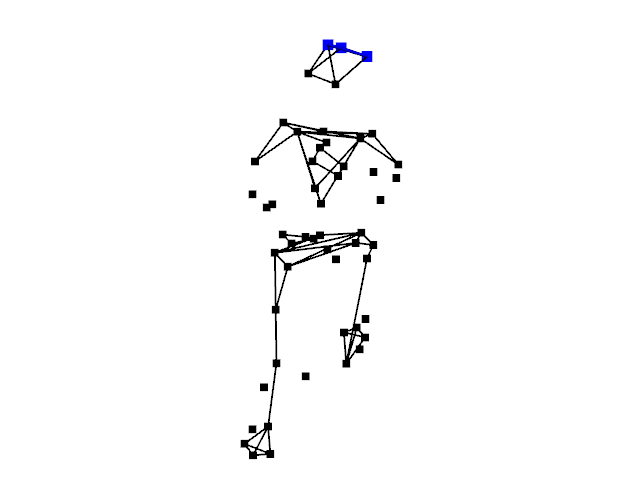

In [719]:
Image(filename=f'animate/{'temp'}.gif')

In [721]:
final_labels[10]

0

In [723]:
df

,index of the starting if seq,label
0,0,2
1,1,0
2,2,3
3,3,2
4,4,3
5,5,1
6,6,2
7,7,2
8,8,3
9,9,3


In [729]:
emb.shape

(40, 128)

In [731]:
final_labels

array([2, 0, 3, 2, 3, 1, 2, 2, 3, 3, 0, 3, 3, 3, 3, 2, 2, 2, 3, 3, 3, 2,
       1, 2, 2, 2, 3, 3, 2, 3, 2, 2, 3, 3, 3, 3, 3, 2, 3, 1])

In [737]:
import pandas as pd
import numpy as np

# Ensure emb is a NumPy array of shape (40, 128)
emb = np.array(emb).reshape(40, 128)

# Ensure final_labels is a column vector of shape (40, 1)
final_labels = np.array(final_labels).reshape(40, 1)

# Convert embeddings into a DataFrame with proper column names
emb_df = pd.DataFrame(emb, columns=[f'feature_{i}' for i in range(128)])

# Convert labels into a DataFrame
labels_df = pd.DataFrame(final_labels, columns=['label'])

# Concatenate both DataFrames
new_df = pd.concat([emb_df, labels_df], axis=1)

print(new_df.shape)  # Should be (40, 129)
print(new_df.head())  # View first few rowsnew

(40, 129)
   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0  -0.101021  -0.079817  -0.070533   0.202322   0.046178  -0.087222   
1  -0.098596  -0.077823  -0.067977   0.196279   0.045547  -0.085015   
2  -0.077007  -0.080859  -0.046766   0.159018   0.037479  -0.062865   
3  -0.074653  -0.099540  -0.040918   0.148727   0.037345  -0.042543   
4  -0.074599  -0.099452  -0.040669   0.147990   0.037279  -0.041878   

   feature_6  feature_7  feature_8  feature_9  ...  feature_119  feature_120  \
0   0.175257  -0.151714  -0.102938  -0.021144  ...    -0.115163     0.094365   
1   0.170954  -0.143166  -0.102404  -0.019555  ...    -0.114347     0.087750   
2   0.156353  -0.089539  -0.081694  -0.002638  ...    -0.111176     0.049509   
3   0.166113  -0.085774  -0.066367   0.001650  ...    -0.107374     0.046246   
4   0.165902  -0.085245  -0.065821   0.001842  ...    -0.106969     0.045884   

   feature_121  feature_122  feature_123  feature_124  feature_125  \
0     0.0740

In [741]:
new_df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,label
0,-0.101021,-0.079817,-0.070533,0.202322,0.046178,-0.087222,0.175257,-0.151714,-0.102938,-0.021144,...,-0.115163,0.094365,0.074048,-0.105775,0.067022,-0.060914,0.106859,0.009942,-0.238929,2
1,-0.098596,-0.077823,-0.067977,0.196279,0.045547,-0.085015,0.170954,-0.143166,-0.102404,-0.019555,...,-0.114347,0.087750,0.071763,-0.101996,0.068289,-0.064666,0.100865,0.008461,-0.229163,0
2,-0.077007,-0.080859,-0.046766,0.159018,0.037479,-0.062865,0.156353,-0.089539,-0.081694,-0.002638,...,-0.111176,0.049509,0.054735,-0.060997,0.077246,-0.085894,0.062744,-0.006692,-0.164449,3
3,-0.074653,-0.099540,-0.040918,0.148727,0.037345,-0.042543,0.166113,-0.085774,-0.066367,0.001650,...,-0.107374,0.046246,0.051400,-0.041869,0.079264,-0.087485,0.059889,-0.016944,-0.159586,2
4,-0.074599,-0.099452,-0.040669,0.147990,0.037279,-0.041878,0.165902,-0.085245,-0.065821,0.001842,...,-0.106969,0.045884,0.051369,-0.041567,0.079675,-0.087164,0.059702,-0.017020,-0.159602,3


In [779]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Converting integer labels to text descriptions
def label_to_text(label):
    descriptions = {
        0: "very little movement in the dance sequence",
        1: "major movement in the upper body with arms and shoulders",
        2: "significant movement in the middle body with torso and waist",
        3: "predominant movement in the lower body with legs and feet"
    }
    return descriptions[label]

# 2. Text Encoder Model
class TextEncoder(nn.Module):
    def __init__(self, output_dim=128):
        super(TextEncoder, self).__init__()
        self.tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
        self.model = AutoModel.from_pretrained("distilbert-base-uncased")
        self.fc = nn.Linear(768, output_dim)  # DistilBERT hidden size is 768
        
    def forward(self, texts):
        # Process a batch of texts
        inputs = self.tokenizer(texts, return_tensors="pt", padding=True, truncation=True)
        
        # Move inputs to the same device as the model
        inputs = {k: v.to(next(self.model.parameters()).device) for k, v in inputs.items()}
        
        outputs = self.model(**inputs)
        # Use CLS token as text representation
        embeddings = outputs.last_hidden_state[:, 0, :]
        embeddings = self.fc(embeddings)
        return F.normalize(embeddings, p=2, dim=1)  # L2 normalize

# 3. Contrastive Learning Loss (NT-Xent)
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super(NTXentLoss, self).__init__()
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss()
        
    def forward(self, motion_embeddings, text_embeddings):
        # Compute similarity matrix
        sim_matrix = torch.matmul(motion_embeddings, text_embeddings.T) / self.temperature
        
        # Labels are the diagonal elements (matching pairs)
        labels = torch.arange(sim_matrix.size(0)).to(motion_embeddings.device)
        
        # Compute loss in both directions (motion->text and text->motion)
        loss_m2t = self.criterion(sim_matrix, labels)
        loss_t2m = self.criterion(sim_matrix.T, labels)
        
        # Average the losses
        loss = (loss_m2t + loss_t2m) / 2
        return loss

# 4. Training function for contrastive learning
def train_contrastive_model(df, epochs=20, batch_size=32, device="cuda" if torch.cuda.is_available() else "cpu"):
    # Extract motion embeddings and labels from dataframe
    motion_embeddings = torch.tensor(df.iloc[:, :128].values, dtype=torch.float32).to(device)
    labels = df.iloc[:, 128].values
    
    # Convert labels to text descriptions
    text_descriptions = [label_to_text(label) for label in labels]
    
    # Initialize text encoder
    text_encoder = TextEncoder(output_dim=128).to(device)
    
    # Initialize loss function
    criterion = NTXentLoss()
    
    # Initialize optimizer
    optimizer = torch.optim.Adam(text_encoder.parameters(), lr=0.001)
    
    # Training loop
    num_samples = len(df)
    num_batches = (num_samples + batch_size - 1) // batch_size
    
    for epoch in range(epochs):
        total_loss = 0
        
        # Shuffle indices
        indices = torch.randperm(num_samples)
        
        for batch_idx in range(num_batches):
            # Get batch indices
            start_idx = batch_idx * batch_size
            end_idx = min((batch_idx + 1) * batch_size, num_samples)
            batch_indices = indices[start_idx:end_idx]
            
            # Get batch data
            batch_motion_embeddings = motion_embeddings[batch_indices]
            batch_text_descriptions = [text_descriptions[i] for i in batch_indices]
            
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward pass
            batch_text_embeddings = text_encoder(batch_text_descriptions)
            
            # Calculate loss
            loss = criterion(batch_motion_embeddings, batch_text_embeddings)
            
            # Backward pass
            loss.backward()
            
            # Update weights
            optimizer.step()
            
            total_loss += loss.item()
        
        # Print progress
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {total_loss / num_batches:.4f}")
    
    return text_encoder

# 5. Evaluate contrastive learning results
def evaluate_contrastive_model(df, text_encoder, device="cuda" if torch.cuda.is_available() else "cpu"):
    # Extract motion embeddings and labels from dataframe
    motion_embeddings = torch.tensor(df.iloc[:, :128].values, dtype=torch.float32).to(device)
    labels = df.iloc[:, 128].values
    
    # Convert labels to text descriptions
    text_descriptions = [label_to_text(label) for label in labels]
    
    # Get text embeddings
    text_encoder.eval()
    with torch.no_grad():
        text_embeddings = text_encoder(text_descriptions)
    
    # Compute similarity matrix
    sim_matrix = torch.matmul(motion_embeddings, text_embeddings.T)
    
    # Get top match for each motion embedding
    top_matches = torch.argmax(sim_matrix, dim=1).cpu().numpy()
    
    # Calculate accuracy
    correct = (top_matches == np.arange(len(labels))).sum()
    accuracy = correct / len(labels)
    
    print(f"Contrastive Learning Accuracy: {accuracy:.4f}")
    
    return sim_matrix, top_matches

# 6. Visualize embeddings
def visualize_embeddings(df, text_encoder, device="cuda" if torch.cuda.is_available() else "cpu"):
    # Extract motion embeddings and labels from dataframe
    motion_embeddings = df.iloc[:, :128].values
    text_embeddings = None
    labels = df.iloc[:, 128].values
    
    # Convert labels to text descriptions and get text embeddings
    text_descriptions = [label_to_text(label) for label in labels]
    
    text_encoder.eval()
    with torch.no_grad():
        text_embeddings = text_encoder(text_descriptions).cpu().numpy()
    
    # Combine both embeddings
    combined_embeddings = np.vstack([motion_embeddings, text_embeddings])
    combined_labels = np.concatenate([labels, labels])
    modality_labels = np.concatenate([np.zeros(len(motion_embeddings)), np.ones(len(text_embeddings))])
    
    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42,n_jobs=1,method='exact')
    embeddings_2d = tsne.fit_transform(combined_embeddings)
    
    # Split embeddings by modality
    motion_tsne = embeddings_2d[:len(motion_embeddings)]
    text_tsne = embeddings_2d[len(motion_embeddings):]
    
    # Plot by category
    plt.figure(figsize=(12, 10))
    
    categories = np.unique(labels)
    markers = ['o', 's']  # circle for motion, square for text
    
    for category in categories:
        # Motion embeddings
        indices = np.where(labels == category)[0]
        plt.scatter(motion_tsne[indices, 0], motion_tsne[indices, 1], 
                    marker=markers[0], label=f"Motion - {label_to_text(category)[:20]}...",
                   alpha=0.7)
        
        # Text embeddings
        plt.scatter(text_tsne[indices, 0], text_tsne[indices, 1], 
                    marker=markers[1], label=f"Text - {label_to_text(category)[:20]}...",
                   alpha=0.7)
    
    plt.legend()
    plt.title("t-SNE Visualization of Motion and Text Embeddings")
    plt.savefig("motion_text_embeddings.png")
    plt.show()

# 7. Main execution function
def main():
    # Load dataframe
    df = new_df
    
    # Check if DataFrame has correct format (128 feature columns + 1 label column)
    assert df.shape[1] == 129, "DataFrame should have 128 feature columns and 1 label column"
    
    # Define device
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")
    
    # Train contrastive model
    text_encoder = train_contrastive_model(df, epochs=100, device=device)
    
    # Evaluate contrastive model
    sim_matrix, top_matches = evaluate_contrastive_model(df, text_encoder, device=device)
    
    # Visualize embeddings
    visualize_embeddings(df, text_encoder, device=device)
    
    # Save trained model
    torch.save(text_encoder.state_dict(), "text_encoder.pth")
    
    return text_encoder

In [787]:
df_train = new_df.loc[:35]

In [807]:
df_test = new_df.loc[35:]

Using device: cpu
Epoch 10/10, Avg Loss: 2.4266
Contrastive Learning Accuracy: 0.0278


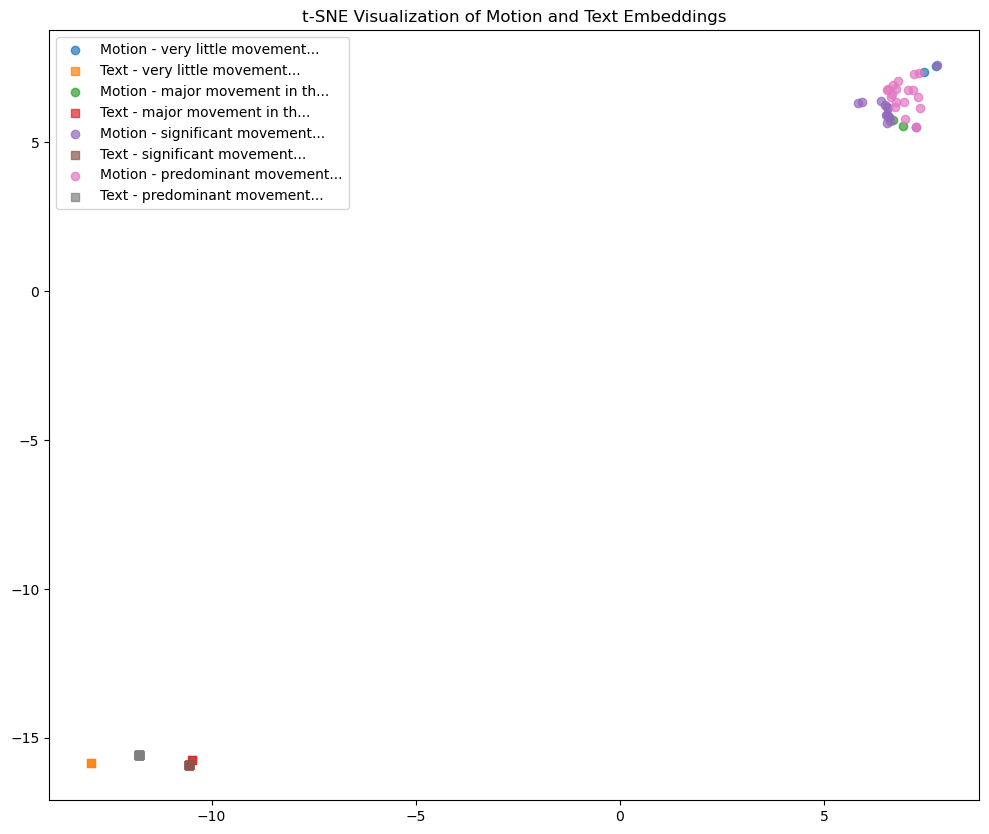

In [793]:
# Check if DataFrame has correct format (128 feature columns + 1 label column)
assert df_train.shape[1] == 129, "DataFrame should have 128 feature columns and 1 label column"

# Define device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
df=df_train
# Train contrastive model
text_encoder = train_contrastive_model(df, epochs=10, device=device)

# Evaluate contrastive model
sim_matrix, top_matches = evaluate_contrastive_model(df, text_encoder, device=device)

# Visualize embeddings
visualize_embeddings(df, text_encoder, device=device)

# Save trained model
torch.save(text_encoder.state_dict(), "text_encoder.pth")

In [823]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt

# Text Encoder Model (same as in your original code)
class TextEncoder(nn.Module):
    def __init__(self, output_dim=128):
        super(TextEncoder, self).__init__()
        self.tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
        self.model = AutoModel.from_pretrained("distilbert-base-uncased")
        self.fc = nn.Linear(768, output_dim)  # DistilBERT hidden size is 768
        
    def forward(self, texts):
        # Process a batch of texts
        inputs = self.tokenizer(texts, return_tensors="pt", padding=True, truncation=True)
        
        # Move inputs to the same device as the model
        inputs = {k: v.to(next(self.model.parameters()).device) for k, v in inputs.items()}
        
        outputs = self.model(**inputs)
        # Use CLS token as text representation
        embeddings = outputs.last_hidden_state[:, 0, :]
        embeddings = self.fc(embeddings)
        return F.normalize(embeddings, p=2, dim=1)  # L2 normalize

# Label to text conversion function
def label_to_text(label):
    descriptions = {
        0: "very little movement in the dance sequence",
        1: "major movement in the upper body with arms and shoulders",
        2: "significant movement in the middle body with torso and waist",
        3: "predominant movement in the lower body with legs and feet"
    }
    return descriptions[label]

# Function to load the trained text encoder
def load_text_encoder(model_path, device="cpu"):
    text_encoder = TextEncoder(output_dim=128).to(device)
    text_encoder.load_state_dict(torch.load(model_path, map_location=device))
    text_encoder.eval()
    return text_encoder

# 1. Generating a dance sequence from natural language input
def generate_dance_from_text(text_input, text_encoder, df_test, device="cpu"):
    """
    Generate a dance sequence from a natural language input by finding the closest match
    in the embedding space.
    
    Args:
        text_input (str): The natural language description of the dance
        text_encoder (TextEncoder): The trained text encoder model
        df_test (pd.DataFrame): Test dataframe with dance features and labels
        device (str): Device to use for computation
        
    Returns:
        dict: Contains the generated dance sequence, similarity score, and dance label
    """
    # Extract motion features and labels from dataframe
    motion_features = torch.tensor(df_test.iloc[:, :128].values, dtype=torch.float32).to(device)
    labels = df_test.iloc[:, 128].values
    
    # Encode the input text
    text_encoder.eval()
    with torch.no_grad():
        text_embedding = text_encoder([text_input])


    print(text_embedding.shape,motion_features.shape)
    # Compute similarity between text embedding and all motion features
    sim_scores = torch.matmul(text_embedding, motion_features.T)
    print(sim_scores.shape)
    # Find the most similar motion
    most_similar_idx = torch.argmax(sim_scores).item()
    most_similar_dance = motion_features[most_similar_idx].cpu().numpy()
    most_similar_score = sim_scores[0, most_similar_idx].item()
    dance_label = labels[most_similar_idx]
    
    return {
        "dance_sequence": most_similar_dance,
        "similarity_score": most_similar_score,
        "dance_label": dance_label,
        "dance_description": label_to_text(dance_label)
    }

# 2. Generating natural language from a dance sequence input
def generate_text_from_dance(dance_idx, df_test, text_encoder, device="cpu"):
    """
    Generate natural language description from a dance sequence by finding the closest match
    in the embedding space.
    
    Args:
        dance_idx (int): Index of the dance sequence in df_test
        df_test (pd.DataFrame): Test dataframe with dance features and labels
        text_encoder (TextEncoder): The trained text encoder model
        device (str): Device to use for computation
        
    Returns:
        dict: Contains the generated text, similarity score, and dance label
    """
    # Extract dance features and label
    dance_features = torch.tensor(df_test.iloc[dance_idx, :128].values, dtype=torch.float32).to(device).unsqueeze(0)
    dance_label = df_test.iloc[dance_idx, 128]
    
    # Get all possible text descriptions
    all_labels = sorted(df_test.iloc[:, 128].unique())
    all_text_descriptions = [label_to_text(label) for label in all_labels]
    
    # Encode all text descriptions
    text_encoder.eval()
    with torch.no_grad():
        text_embeddings = text_encoder(all_text_descriptions)
    
    # Compute similarity
    sim_scores = torch.matmul(dance_features, text_embeddings.T)
    
    # Find most similar text
    most_similar_idx = torch.argmax(sim_scores).item()
    most_similar_text = all_text_descriptions[most_similar_idx]
    most_similar_score = sim_scores[0, most_similar_idx].item()
    
    return {
        "generated_text": most_similar_text,
        "similarity_score": most_similar_score,
        "dance_label": dance_label,
        "dance_description": label_to_text(dance_label)
    }

# Example usage
def main():
    # Load the test data
    # df_test = pd.read_csv("path_to_test_data.csv")  # Replace with your test data path
    
    # Check if DataFrame has correct format (128 feature columns + 1 label column)
    assert df_test.shape[1] == 129, "DataFrame should have 128 feature columns and 1 label column"
    
    # Define device
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")
    
    # Load the trained text encoder
    text_encoder = load_text_encoder("text_encoder.pth", device)
    
    # Example 1: Generate dance from text
    print("\nExample 1: Generating dance sequence from text")
    
    input_text = "significant movement in the middle body with torso and waist"
    dance_result = generate_dance_from_text(input_text, text_encoder, df_test, device)
    
    print(f"Input text: {input_text}")
    print(f"Generated dance label: {dance_result['dance_label']} - {dance_result['dance_description']}")
    print(f"Similarity score: {dance_result['similarity_score']:.4f}")
    print(f"Dance sequence (first 5 features): {dance_result['dance_sequence'][:5]}")
    
    # Example 2: Generate text from dance
    print("\nExample 2: Generating text from dance sequence")
    
    dance_idx = 0  # Use the first dance sequence in the test set
    text_result = generate_text_from_dance(dance_idx, df_test, text_encoder, device)
    
    actual_dance_description = label_to_text(text_result['dance_label'])
    
    print(f"Input dance label: {text_result['dance_label']} - {actual_dance_description}")
    print(f"Generated text: {text_result['generated_text']}")
    print(f"Similarity score: {text_result['similarity_score']:.4f}")
    print(f"Prediction correct: {actual_dance_description == text_result['generated_text']}")
    
    # Bonus: Compare with prediction accuracy on the whole test set
    def evaluate_dance_to_text_accuracy(df_test, text_encoder, device):
        correct = 0
        total = len(df_test)
        
        for idx in range(total):
            result = generate_text_from_dance(idx, df_test, text_encoder, device)
            if label_to_text(result['dance_label']) == result['generated_text']:
                correct += 1
                print(result['generated_text'])
        
        accuracy = correct / total
        print(f"\nOverall dance-to-text accuracy: {accuracy:.4f} ({correct}/{total})")
    
    # Uncomment to run full evaluation (may take time on large datasets)
    # evaluate_dance_to_text_accuracy(df_test, text_encoder, device)

In [831]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load the trained text encoder
text_encoder = load_text_encoder("text_encoder.pth", device)

# Example 1: Generate dance from text
print("\nExample 1: Generating dance sequence from text")

input_text = "major movement in the upper body with arms and shoulders"
dance_result = generate_dance_from_text(input_text, text_encoder, df_test, device)

print(f"Input text: {input_text}")
print(f"Generated dance label: {dance_result['dance_label']} - {dance_result['dance_description']}")
print(f"Similarity score: {dance_result['similarity_score']:.4f}")
print(f"Dance sequence (first 5 features): {dance_result['dance_sequence'][:5]}")


Using device: cpu

Example 1: Generating dance sequence from text
torch.Size([1, 128]) torch.Size([5, 128])
torch.Size([1, 5])
Input text: major movement in the upper body with arms and shoulders
Generated dance label: 3 - predominant movement in the lower body with legs and feet
Similarity score: -0.3015
Dance sequence (first 5 features): [-0.0941525  -0.06701026 -0.03915597  0.16011213  0.04256379]


In [827]:
df_test

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,label
35,-0.094152,-0.067010,-0.039156,0.160112,0.042564,-0.056202,0.145794,-0.079893,-0.079565,-0.012684,...,-0.106751,0.054853,0.050579,-0.068852,0.089542,-0.071049,0.062780,-0.010033,-0.176055,3
36,-0.102708,-0.060722,-0.040407,0.157634,0.044283,-0.058165,0.140200,-0.066365,-0.082352,-0.015919,...,-0.102805,0.050269,0.050401,-0.076258,0.095624,-0.063510,0.052599,-0.000683,-0.177751,3
37,-0.096355,-0.066653,-0.031614,0.145740,0.043519,-0.047346,0.136815,-0.052825,-0.073060,-0.011659,...,-0.097512,0.042589,0.053540,-0.069278,0.101333,-0.057261,0.041612,0.000143,-0.170657,2
38,-0.101558,-0.061882,-0.053338,0.165817,0.044200,-0.069465,0.146479,-0.087338,-0.092022,-0.017052,...,-0.103841,0.054861,0.055031,-0.085917,0.085924,-0.070209,0.066946,0.003193,-0.188932,3
39,-0.068605,-0.088387,-0.032769,0.130185,0.038775,-0.040066,0.153668,-0.066517,-0.065299,-0.002499,...,-0.098950,0.039741,0.053055,-0.050944,0.091356,-0.070107,0.051491,-0.006817,-0.167340,1


In [815]:
print("\nExample 2: Generating text from dance sequence")

dance_idx = 0  # Use the first dance sequence in the test set
text_result = generate_text_from_dance(dance_idx, df_test, text_encoder, device)

actual_dance_description = label_to_text(text_result['dance_label'])

print(f"Input dance label: {text_result['dance_label']} - {actual_dance_description}")
print(f"Generated text: {text_result['generated_text']}")
print(f"Similarity score: {text_result['similarity_score']:.4f}")
print(f"Prediction correct: {actual_dance_description == text_result['generated_text']}")


Example 2: Generating text from dance sequence
Input dance label: 3 - predominant movement in the lower body with legs and feet
Generated text: major movement in the upper body with arms and shoulders
Similarity score: -0.3015
Prediction correct: False


In [833]:
def evaluate_dance_to_text_accuracy(df_test, text_encoder, device):
    correct = 0
    total = len(df_test)
    
    for idx in range(total):
        result = generate_text_from_dance(idx, df_test, text_encoder, device)
        if label_to_text(result['dance_label']) == result['generated_text']:
            correct += 1
            print(result['generated_text'])
            
    
    accuracy = correct / total
    print(f"\nOverall dance-to-text accuracy: {accuracy:.4f} ({correct}/{total})")

# Uncomment to run full evaluation (may take time on large datasets)
evaluate_dance_to_text_accuracy(df_test, text_encoder, device)

major movement in the upper body with arms and shoulders

Overall dance-to-text accuracy: 0.2000 (1/5)
